---
Preliminary analysis of correlations between grain boundary character and hardness values using XGBoost
---

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Opening the data file and analyzing columns and data types
* Use `pandas` to read `data/Berkovich nanoindentation vs Block Parameters.xlsx` (only sheet `H_(E-2)`)
* Numerical data starts from the third row of the excel file
* Missing data is ignored

In [9]:
file_path = "data/Berkovich nanoindentation vs Block Parameters.xlsx"
df = pd.read_excel(
    file_path,
    sheet_name="H_(E-2)",
    skiprows=2,
    header=None,
    usecols=[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11],
    names=[
        "Index",
        "Test",
        "Hardness (GPa)",
        "Distance (um)",
        "Misorientation (degrees)",
        "Euler angle 1 (indent)",
        "Euler angle 2 (indent)",
        "Euler angle 3 (indent)",
        "Euler angle 1 (neighbor)",
        "Euler angle 2 (neighbor)",
        "Euler angle 3 (neighbor)",
    ],
).dropna()

df.describe()
df.head()

,Index,Test,Hardness (GPa),Distance (um),Misorientation (degrees),Euler angle 1 (indent),Euler angle 2 (indent),Euler angle 3 (indent),Euler angle 1 (neighbor),Euler angle 2 (neighbor),Euler angle 3 (neighbor)
0,1.0,2_214,5.05322,0.52,9.16,33.34,11.57,8.99,78.67,7.54,52.86
1,2.0,2_62,5.30000,0.35,17.19,144.41,9.60,31.50,186.55,21.53,87.51
2,3.0,2_28,4.60000,0.40,13.78,44.55,2.69,19.63,60.93,4.65,20.10
3,4.0,2_98,5.00000,0.34,12.97,204.64,25.14,73.44,222.25,18.38,66.66
4,5.0,2_79,4.50000,0.41,27.76,207.77,9.53,49.35,284.88,25.32,47.08


In [10]:
# compute misorientation axis and angle
from scripts.utils.rotation_matrix import rotation_matrix, get_misorientation_angle_axis

euler_1 = df[["Euler angle 1 (indent)", "Euler angle 2 (indent)", "Euler angle 3 (indent)"]].values
euler_2 = df[["Euler angle 1 (neighbor)", "Euler angle 2 (neighbor)", "Euler angle 3 (neighbor)"]].values

R1 = np.array([rotation_matrix(*angles, degrees=True) for angles in euler_1])
R2 = np.array([rotation_matrix(*angles, degrees=True) for angles in euler_2])
misorientation_angles = []
misorientation_axes = []
for i in range(len(R1)):
    theta, axis = get_misorientation_angle_axis(R1[i], R2[i], degrees=True)
    misorientation_angles.append(theta)
    misorientation_axes.append(axis)
df["Misorientation axis 1"] = [axis[0] for axis in misorientation_axes]
df["Misorientation axis 2"] = [axis[1] for axis in misorientation_axes]
df["Misorientation axis 3"] = [axis[2] for axis in misorientation_axes]

 /home/aditya/Documents/projects/iastate_gb_indentation/iastate/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning:IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [11]:
inputs = df.iloc[:, 3:9].values
outputs = df.iloc[:, 2].values.reshape(-1, 1)

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

indx = np.arange(inputs.shape[0])

indx_train, indx_test, inputs_train, inputs_test, outputs_train, outputs_test = train_test_split(
    indx,
    inputs,
    outputs,
    test_size=0.2,
    random_state=42,
)

input_scaler = MinMaxScaler()
output_scaler = MinMaxScaler()

Xtrain = input_scaler.fit_transform(inputs_train)
Xtest = input_scaler.transform(inputs_test)
Ytrain = output_scaler.fit_transform(outputs_train)
Ytest = output_scaler.transform(outputs_test)

In [12]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
)
model.fit(Xtrain, Ytrain.ravel())

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
ytest_pred = model.predict(Xtest).reshape(-1, 1)

# Scale predictions back to the original hardness units.
ytest_pred_original = output_scaler.inverse_transform(ytest_pred)
outputs_test_original = output_scaler.inverse_transform(Ytest)

# XGBoost does not provide GP-style predictive variance by default.
ytest_std_original = None

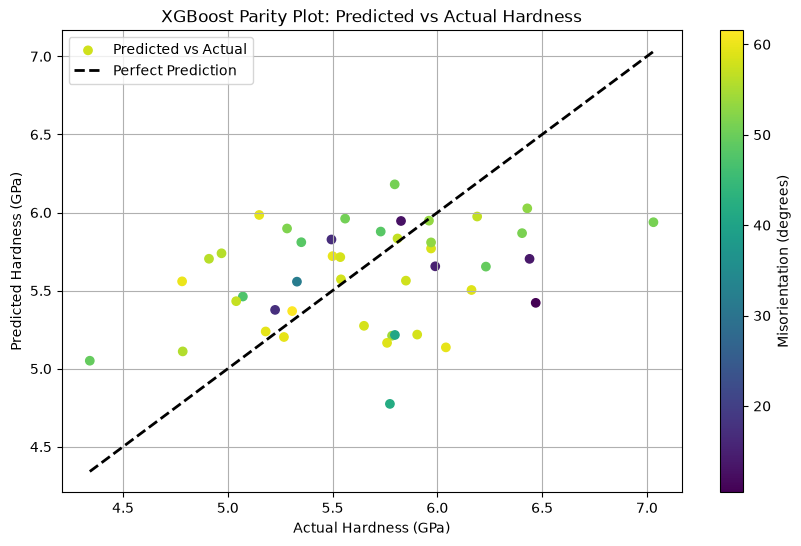

In [14]:
# Parity plot between predicted and actual hardness values.
plt.figure(figsize=(10, 6))
plt.scatter(
    outputs_test_original.ravel(),
    ytest_pred_original.ravel(),
    c=inputs_test[:, 1],
    label="Predicted vs Actual",
)
plt.plot(
    [outputs_test_original.min(), outputs_test_original.max()],
    [outputs_test_original.min(), outputs_test_original.max()],
    "k--",
    lw=2,
    label="Perfect Prediction",
)
plt.xlabel("Actual Hardness (GPa)")
plt.ylabel("Predicted Hardness (GPa)")
plt.title("XGBoost Parity Plot: Predicted vs Actual Hardness")
plt.colorbar(label="Misorientation (degrees)")
plt.legend()
plt.grid()
plt.show()